In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)
library(RColorBrewer)
library(viridis)
library(cowplot)

### 1. Multiple shifts (sd)

In [3]:
set.seed(19)
yule_tree = sim.bd.taxa(16, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

PCs = eigen(vcv(yule_tree))$vectors

colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 8
PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

shifts = 10^(seq(log10(1e-4),log10(1e4), len=10))

num_rep = 100
n_edges = length(yule_tree$edge) / 2
n_tips = n_edges / 2 + 1
yule_tree_l = sum(yule_tree$edge.length)
probs = yule_tree$edge.length / yule_tree_l


branch_cands = c(1, 2, 11, 15, 17, 23, 24, 25, 26)
n_branch_cands = length(branch_cands)
n_pairs = n_branch_cands * (n_branch_cands - 1) / 2
n_rows = length(shifts) * num_rep * length(PC_sets) * n_pairs

In [4]:
p_vals_PC_4 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]
    shift = formatC(shift, format = "e", digits = 3)

    e_1 = yule_tree$edge[1,]
    descendants_1 = getDescendants(yule_tree, e_1[2])
    descendants_tips_1 = descendants_1[descendants_1 <= n_tips]
    e_2 = yule_tree$edge[2,]
    descendants_2 = getDescendants(yule_tree, e_2[2])
    descendants_tips_2 = descendants_2[descendants_2 <= n_tips]
    e_3 = yule_tree$edge[23,]
    descendants_3 = getDescendants(yule_tree, e_3[2])
    descendants_tips_3 = descendants_3[descendants_3 <= n_tips]
    e_4 = yule_tree$edge[25,]
    descendants_4 = getDescendants(yule_tree, e_4[2])
    descendants_tips_4 = descendants_4[descendants_4 <= n_tips]


    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]  
        X[descendants_tips_1] = X[descendants_tips_1] + rnorm(1,0,sd=sqrt(shifts[i]))
        Y[descendants_tips_1] = Y[descendants_tips_1] + rnorm(1,0,sd=sqrt(shifts[i]))
        X[descendants_tips_2] = X[descendants_tips_2] + rnorm(1,0,sd=sqrt(shifts[i]))
        Y[descendants_tips_2] = Y[descendants_tips_2] + rnorm(1,0,sd=sqrt(shifts[i]))
        X[descendants_tips_3] = X[descendants_tips_3] + rnorm(1,0,sd=sqrt(shifts[i]))
        Y[descendants_tips_3] = Y[descendants_tips_3] + rnorm(1,0,sd=sqrt(shifts[i]))
        X[descendants_tips_4] = X[descendants_tips_4] + rnorm(1,0,sd=sqrt(shifts[i]))
        Y[descendants_tips_4] = Y[descendants_tips_4] + rnorm(1,0,sd=sqrt(shifts[i]))
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
            tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
                    p_vals_PC_4[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,
                                              "shifts" = shift)]
            }, error = function(e) {
                    p_vals_PC_4[counter, `:=`("PCs" = l - 1, "p.value" = NA,
                                              "shifts" = shift)]
            })
            counter = counter + 1
        }                           
    }  
}

Testing for shift size: 1

Testing for shift size: 2

Testing for shift size: 3

Testing for shift size: 4

Testing for shift size: 5

Testing for shift size: 6

Testing for shift size: 7

Testing for shift size: 8

Testing for shift size: 9

Testing for shift size: 10



In [5]:
p_vals_PC_summary_4 = p_vals_PC_4 %>% group_by(PCs, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_PC_summary_4$sd.shift = sqrt(as.numeric(p_vals_PC_summary_4$shifts))

p_vals_PC_summary_4 = as.data.table(p_vals_PC_summary_4) 
p_vals_PC_summary_4$shifts = factor(p_vals_PC_summary_4$shifts)

In [6]:
plot_shift_4 <- p_vals_PC_summary_4 %>% 
    ggplot(aes(PCs,FPR, group = sd.shift)) +
    geom_line(aes(color = log10(sd.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          egend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "viridis",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(sd(shift))"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 1,               # width of color bar
           barheight = 10              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


In [7]:
p_vals_PC_8 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 11, 15, 17, 23, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]
    shift = formatC(shift, format = "e", digits = 3)

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
            Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
        }
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
            tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
                    p_vals_PC_8[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,
                                              "shifts" = shift)]
            }, error = function(e) {
                    p_vals_PC_8[counter, `:=`("PCs" = l - 1, "p.value" = NA,
                                              "shifts" = shift)]
            })
            counter = counter + 1
        }                           
    }  
}

Testing for shift size: 1

Testing for shift size: 2

Testing for shift size: 3

Testing for shift size: 4

Testing for shift size: 5

Testing for shift size: 6

Testing for shift size: 7

Testing for shift size: 8

Testing for shift size: 9

Testing for shift size: 10



In [8]:
p_vals_PC_summary_8 = p_vals_PC_8 %>% group_by(PCs, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_PC_summary_8$sd.shift = sqrt(as.numeric(p_vals_PC_summary_8$shifts))

p_vals_PC_summary_8 = as.data.table(p_vals_PC_summary_8) 
p_vals_PC_summary_8$shifts = factor(p_vals_PC_summary_8$shifts)

In [9]:
plot_shift_8 <- p_vals_PC_summary_8 %>% 
    ggplot(aes(PCs,FPR, group = sd.shift)) +
    geom_line(aes(color = log10(sd.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          egend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "viridis",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(sd(shift))"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 1,               # width of color bar
           barheight = 10              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

In [10]:
p_vals_PC_12 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 9, 10, 11, 15, 17, 18, 23, 24, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]
    shift = formatC(shift, format = "e", digits = 3)

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
            Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
        }
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
            tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
                    p_vals_PC_12[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,
                                              "shifts" = shift)]
            }, error = function(e) {
                    p_vals_PC_12[counter, `:=`("PCs" = l - 1, "p.value" = NA,
                                              "shifts" = shift)]
            })
            counter = counter + 1
        }                           
    }  
}

Testing for shift size: 1

Testing for shift size: 2

Testing for shift size: 3

Testing for shift size: 4

Testing for shift size: 5

Testing for shift size: 6

Testing for shift size: 7

Testing for shift size: 8

Testing for shift size: 9

Testing for shift size: 10



In [11]:
p_vals_PC_summary_12 = p_vals_PC_12 %>% group_by(PCs, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_PC_summary_12$sd.shift = sqrt(as.numeric(p_vals_PC_summary_12$shifts))

p_vals_PC_summary_12 = as.data.table(p_vals_PC_summary_12) 
p_vals_PC_summary_12$shifts = factor(p_vals_PC_summary_12$shifts)

In [12]:
plot_shift_12 <- p_vals_PC_summary_12 %>% 
    ggplot(aes(PCs,FPR, group = sd.shift)) +
    geom_line(aes(color = log10(sd.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          egend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "viridis",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(sd(shift))"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 1,               # width of color bar
           barheight = 10              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

### 2. Multiple Shifts (mean)

In [13]:
shifts_2 = sqrt(shifts)

p_vals_PC_5 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts_2[i]
    shift = formatC(shift, format = "e", digits = 3)

    e_1 = yule_tree$edge[1,]
    descendants_1 = getDescendants(yule_tree, e_1[2])
    descendants_tips_1 = descendants_1[descendants_1 <= n_tips]
    e_2 = yule_tree$edge[2,]
    descendants_2 = getDescendants(yule_tree, e_2[2])
    descendants_tips_2 = descendants_2[descendants_2 <= n_tips]
    e_3 = yule_tree$edge[23,]
    descendants_3 = getDescendants(yule_tree, e_3[2])
    descendants_tips_3 = descendants_3[descendants_3 <= n_tips]
    e_4 = yule_tree$edge[25,]
    descendants_4 = getDescendants(yule_tree, e_4[2])
    descendants_tips_4 = descendants_4[descendants_4 <= n_tips]


    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]  
        X[descendants_tips_1] = X[descendants_tips_1] + shifts_2[i]
        Y[descendants_tips_1] = Y[descendants_tips_1] + shifts_2[i]
        X[descendants_tips_2] = X[descendants_tips_2] + shifts_2[i]
        Y[descendants_tips_2] = Y[descendants_tips_2] + shifts_2[i]
        X[descendants_tips_3] = X[descendants_tips_3] + shifts_2[i]
        Y[descendants_tips_3] = Y[descendants_tips_3] + shifts_2[i]
        X[descendants_tips_4] = X[descendants_tips_4] + shifts_2[i]
        Y[descendants_tips_4] = Y[descendants_tips_4] + shifts_2[i]
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
            tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
                    p_vals_PC_5[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,
                                              "shifts" = shift)]
            }, error = function(e) {
                    p_vals_PC_5[counter, `:=`("PCs" = l - 1, "p.value" = NA,
                                              "shifts" = shift)]
            })
            counter = counter + 1
        }                           
    }  
}

Testing for shift size: 1

Testing for shift size: 2

Testing for shift size: 3

Testing for shift size: 4

Testing for shift size: 5

Testing for shift size: 6

Testing for shift size: 7

Testing for shift size: 8

Testing for shift size: 9

Testing for shift size: 10



In [14]:
p_vals_PC_summary_5 = p_vals_PC_5 %>% group_by(PCs, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_PC_summary_5$mean.shift = as.numeric(p_vals_PC_summary_5$shifts)

p_vals_PC_summary_5 = as.data.table(p_vals_PC_summary_5) 
p_vals_PC_summary_5$shifts = factor(p_vals_PC_summary_5$shifts)

In [15]:
plot_shift_5 <- p_vals_PC_summary_5 %>% 
    ggplot(aes(PCs,FPR, group = mean.shift)) +
    geom_line(aes(color = log10(mean.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          egend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "magma",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(shift)"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 1,               # width of color bar
           barheight = 10              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

In [16]:
p_vals_PC_9 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 11, 15, 17, 23, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts_2)) {
    message("Testing for shift size: ", i)
    shift = shifts_2[i]
    shift = formatC(shift, format = "e", digits = 3)

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + shifts_2[i]
            Y[descendants_tips] = Y[descendants_tips] + shifts_2[i]
        }
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
            tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
                    p_vals_PC_9[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,
                                              "shifts" = shift)]
            }, error = function(e) {
                    p_vals_PC_9[counter, `:=`("PCs" = l - 1, "p.value" = NA,
                                              "shifts" = shift)]
            })
            counter = counter + 1
        }                           
    }  
}

Testing for shift size: 1

Testing for shift size: 2

Testing for shift size: 3

Testing for shift size: 4

Testing for shift size: 5

Testing for shift size: 6

Testing for shift size: 7

Testing for shift size: 8

Testing for shift size: 9

Testing for shift size: 10



In [17]:
p_vals_PC_summary_9 = p_vals_PC_9 %>% group_by(PCs, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_PC_summary_9$mean.shift = as.numeric(p_vals_PC_summary_9$shifts)

p_vals_PC_summary_9 = as.data.table(p_vals_PC_summary_9) 
p_vals_PC_summary_9$shifts = factor(p_vals_PC_summary_9$shifts)

In [18]:
plot_shift_9 <- p_vals_PC_summary_9 %>% 
    ggplot(aes(PCs,FPR, group = mean.shift)) +
    geom_line(aes(color = log10(mean.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          egend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "magma",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(shift)"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 1,               # width of color bar
           barheight = 10              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

In [19]:
p_vals_PC_13 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 9, 10, 11, 15, 17, 18, 23, 24, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts_2)) {
    message("Testing for shift size: ", i)
    shift = shifts_2[i]
    shift = formatC(shift, format = "e", digits = 3)

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + shifts_2[i]
            Y[descendants_tips] = Y[descendants_tips] + shifts_2[i]
        }
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
            tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
                    p_vals_PC_13[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,
                                              "shifts" = shift)]
            }, error = function(e) {
                    p_vals_PC_13[counter, `:=`("PCs" = l - 1, "p.value" = NA,
                                              "shifts" = shift)]
            })
            counter = counter + 1
        }                           
    }  
}

Testing for shift size: 1

Testing for shift size: 2

Testing for shift size: 3

Testing for shift size: 4

Testing for shift size: 5

Testing for shift size: 6

Testing for shift size: 7

Testing for shift size: 8

Testing for shift size: 9

Testing for shift size: 10



In [20]:
p_vals_PC_summary_13 = p_vals_PC_13 %>% group_by(PCs, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_PC_summary_13$mean.shift = as.numeric(p_vals_PC_summary_13$shifts)

p_vals_PC_summary_13 = as.data.table(p_vals_PC_summary_13) 
p_vals_PC_summary_13$shifts = factor(p_vals_PC_summary_13$shifts)

In [21]:
plot_shift_13 <- p_vals_PC_summary_13 %>% 
    ggplot(aes(PCs,FPR, group = mean.shift)) +
    geom_line(aes(color = log10(mean.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          egend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "magma",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(shift)"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 1,               # width of color bar
           barheight = 10              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

### 3. Plotting

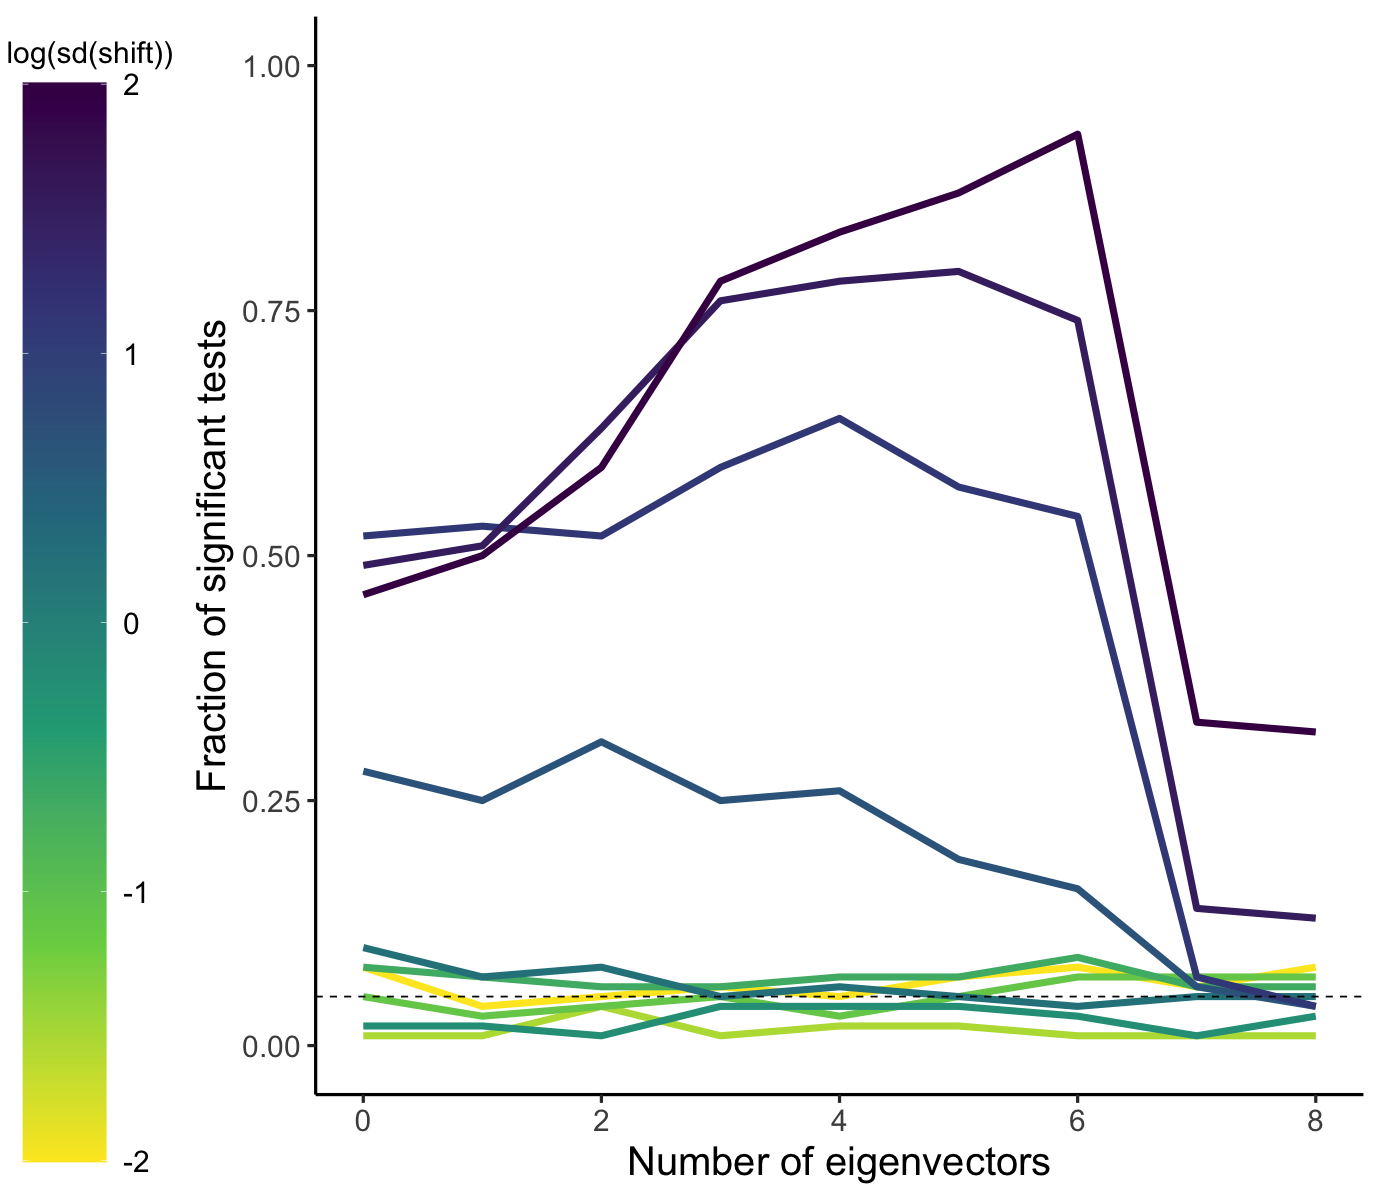

In [22]:
options(repr.plot.width = 11.5, repr.plot.height = 10)

plot_shift_4 <- p_vals_PC_summary_4 %>%
    ggplot(aes(PCs,FPR, group = sd.shift)) +
    geom_line(aes(color = log10(sd.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) +
    theme(
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          legend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "viridis",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(sd(shift))"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 3.5,               # width of color bar
           barheight = 45              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

legend_4 <- get_legend(plot_shift_4)

plot_shift_4_no_legend <- plot_shift_4 + theme(legend.position = "none")

final_plot_4 <- plot_grid(
  legend_4, plot_shift_4_no_legend,
  ncol = 2,
  rel_widths = c(0.15, 1),
  align = "none"
)

final_plot_4

ggsave("Figures_raw/Figure_4_3.5_sd.pdf", final_plot_4, width = 11.5, height = 10)
ggsave("Figures_raw/Figure_4_3.5_sd.svg", final_plot_4, width = 11.5, height = 10)

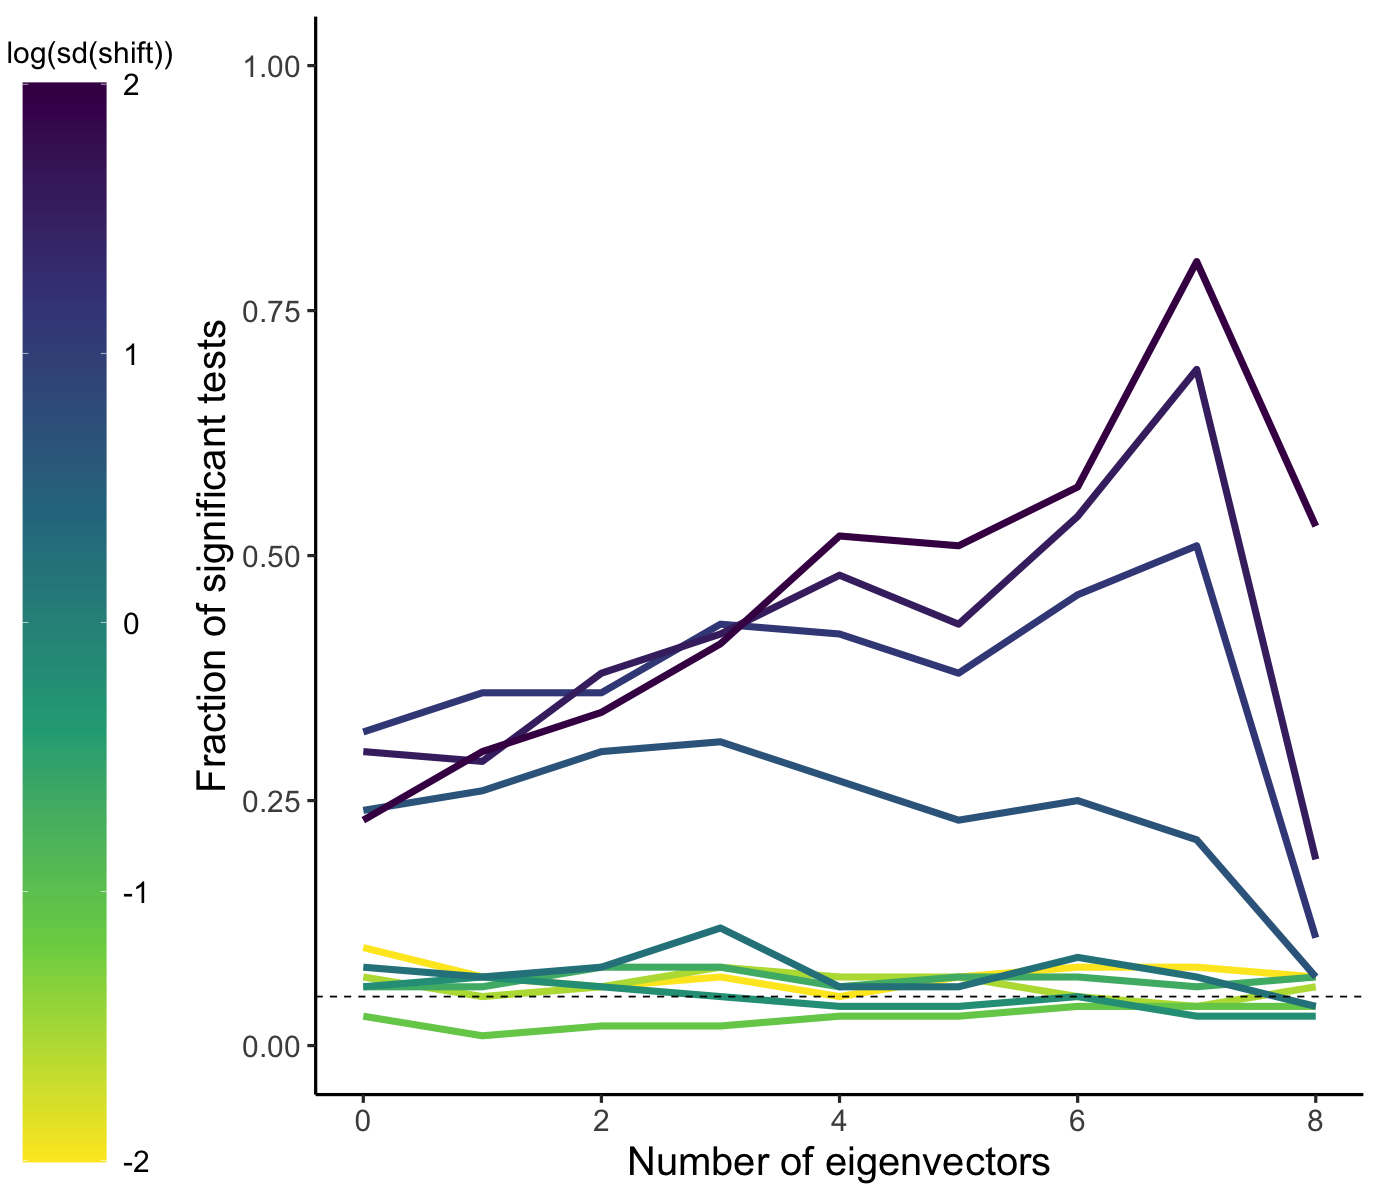

In [23]:
options(repr.plot.width = 11.5, repr.plot.height = 10)

plot_shift_8 <- p_vals_PC_summary_8 %>%
    ggplot(aes(PCs,FPR, group = sd.shift)) +
    geom_line(aes(color = log10(sd.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) +
    theme(
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          legend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "viridis",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(sd(shift))"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 3.5,               # width of color bar
           barheight = 45              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

legend_8 <- get_legend(plot_shift_8)

plot_shift_8_no_legend <- plot_shift_8 + theme(legend.position = "none")

final_plot_8 <- plot_grid(
  legend_8, plot_shift_8_no_legend,
  ncol = 2,
  rel_widths = c(0.15, 1),
  align = "none"
)

final_plot_8

ggsave("Figures_raw/Figure_4_3.6_sd.pdf", final_plot_8, width = 11.5, height = 10)
ggsave("Figures_raw/Figure_4_3.6_sd.svg", final_plot_8, width = 11.5, height = 10)

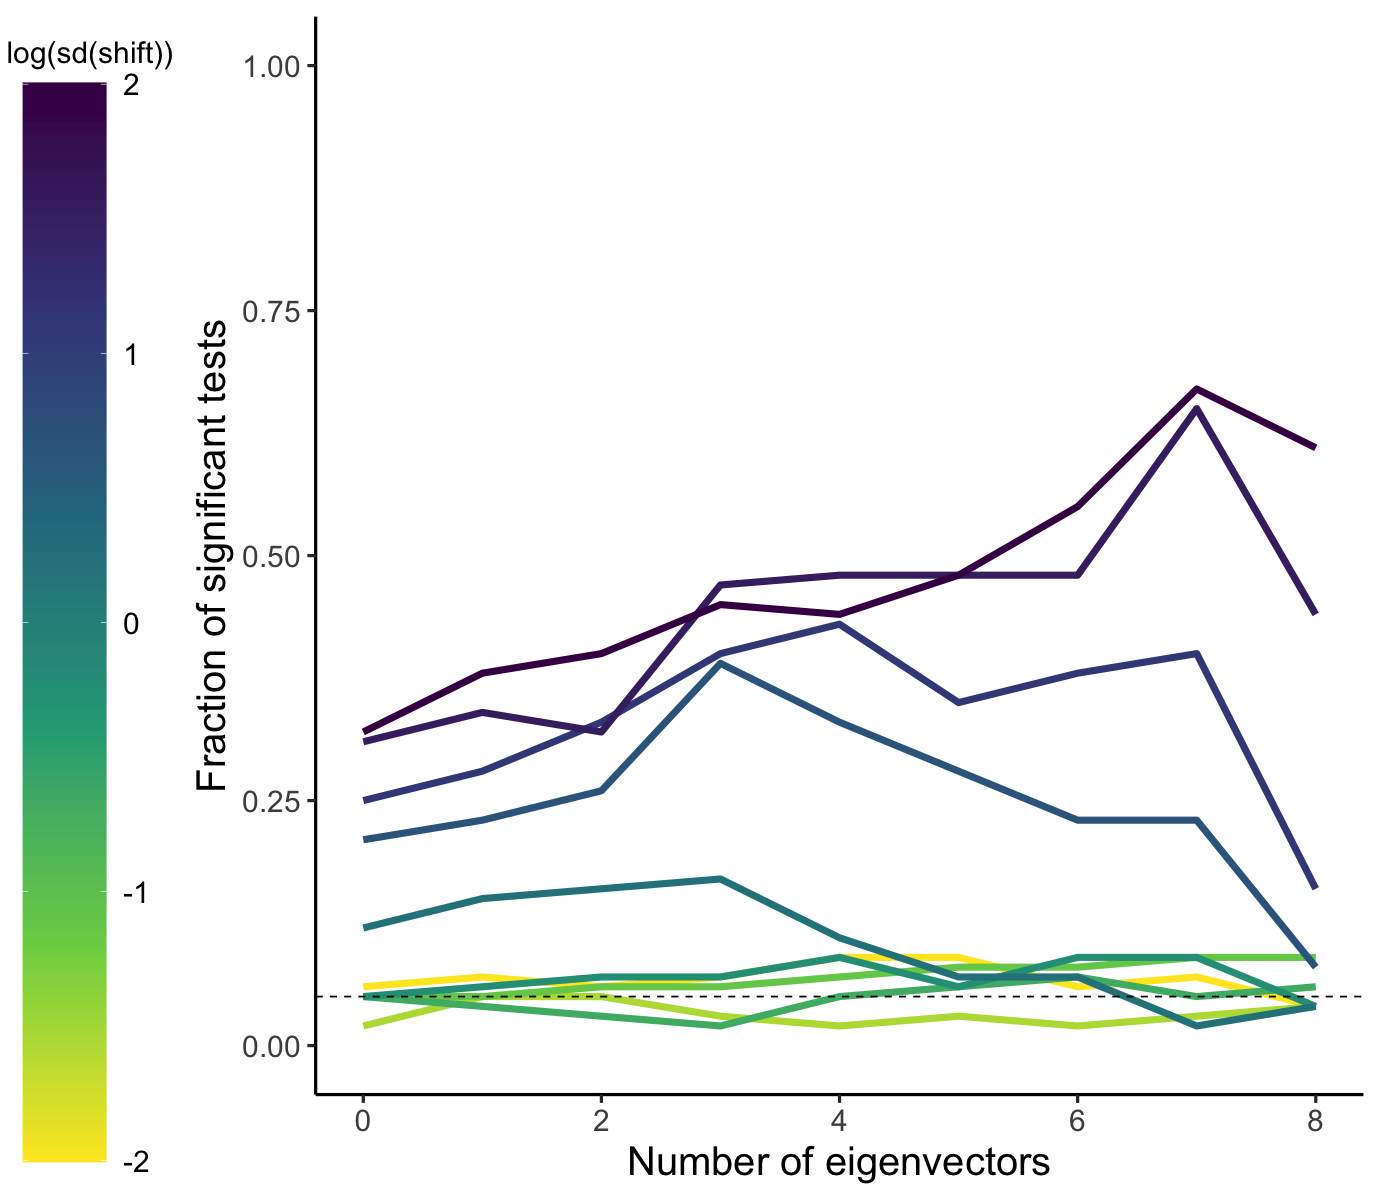

In [24]:
options(repr.plot.width = 11.5, repr.plot.height = 10)

plot_shift_12 <- p_vals_PC_summary_12 %>%
    ggplot(aes(PCs,FPR, group = sd.shift)) +
    geom_line(aes(color = log10(sd.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) +
    theme(
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          legend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "viridis",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(sd(shift))"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 3.5,               # width of color bar
           barheight = 45              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

legend_12 <- get_legend(plot_shift_12)

plot_shift_12_no_legend <- plot_shift_12 + theme(legend.position = "none")

final_plot_12 <- plot_grid(
  legend_12, plot_shift_12_no_legend,
  ncol = 2,
  rel_widths = c(0.15, 1),
  align = "none"
)

final_plot_12

ggsave("Figures_raw/Figure_4_3.7_sd.pdf", final_plot_12, width = 11.5, height = 10)
ggsave("Figures_raw/Figure_4_3.7_sd.svg", final_plot_12, width = 11.5, height = 10)

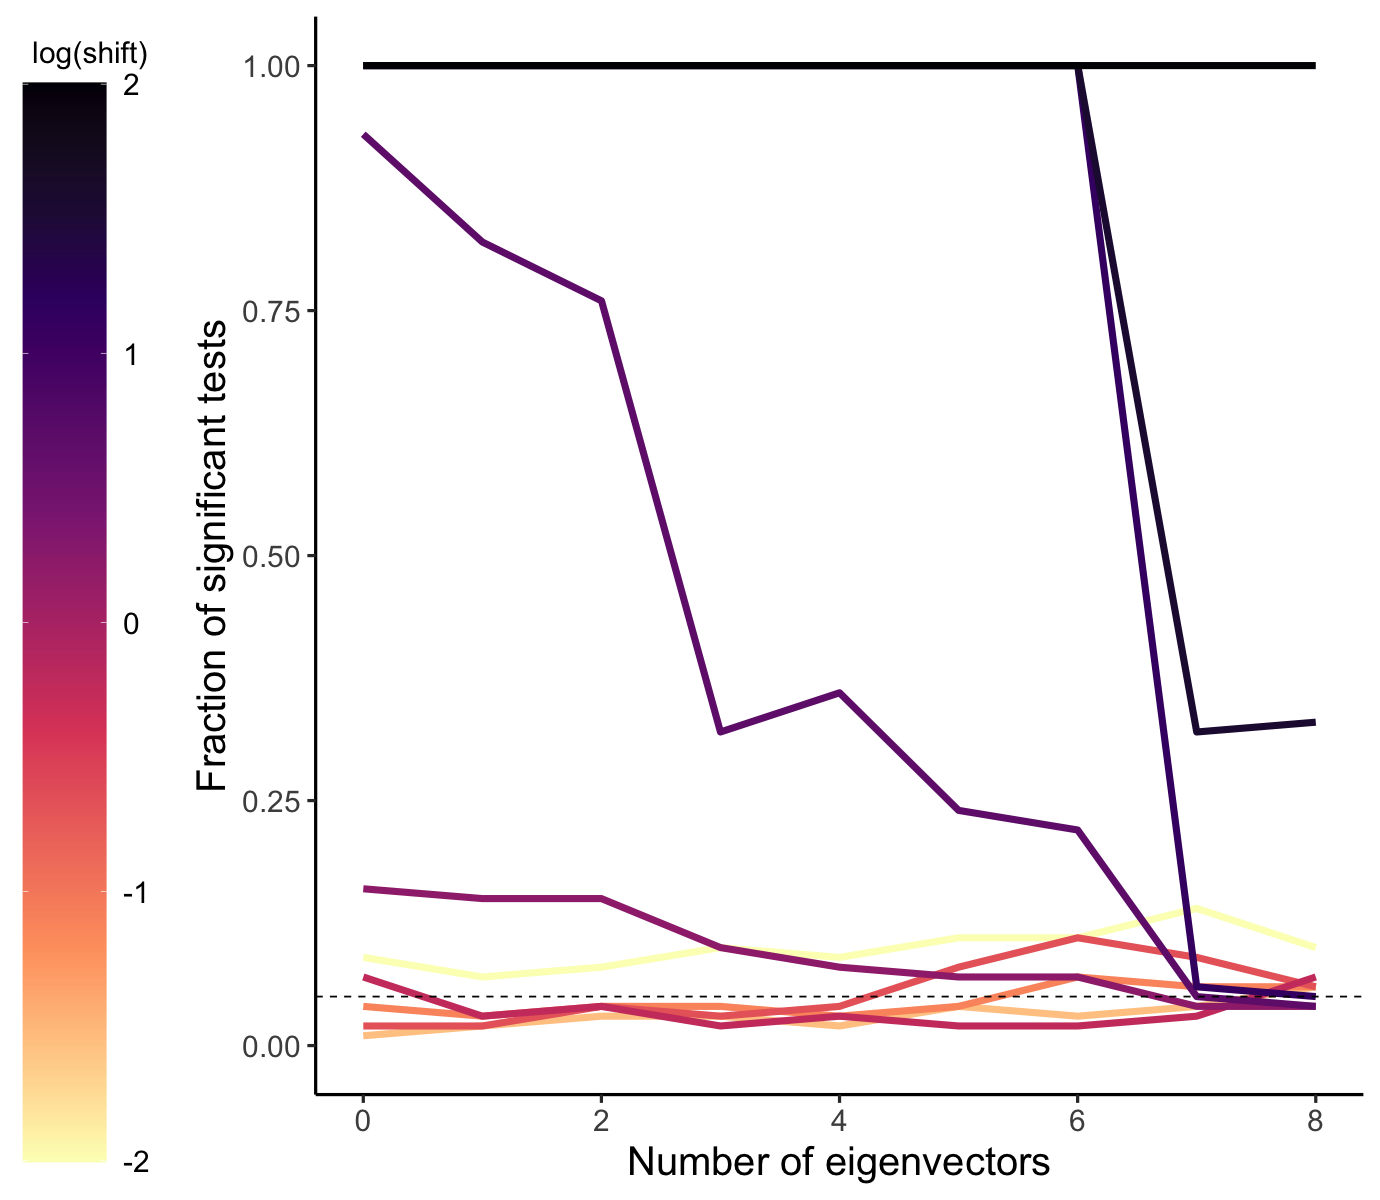

In [25]:
options(repr.plot.width = 11.5, repr.plot.height = 10)

plot_shift_5 <- p_vals_PC_summary_5 %>%
    ggplot(aes(PCs,FPR, group = mean.shift)) +
    geom_line(aes(color = log10(mean.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) +
    theme(
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          legend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "magma",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(shift)"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 3.5,               # width of color bar
           barheight = 45              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

legend_5 <- get_legend(plot_shift_5)

plot_shift_5_no_legend <- plot_shift_5 + theme(legend.position = "none")

final_plot_5 <- plot_grid(
  legend_5, plot_shift_5_no_legend,
  ncol = 2,
  rel_widths = c(0.15, 1),
  align = "none"
)

final_plot_5

ggsave("Figures_raw/Figure_4_3.8_mean.pdf", final_plot_5, width = 11.5, height = 10)
ggsave("Figures_raw/Figure_4_3.8_mean.svg", final_plot_5, width = 11.5, height = 10)

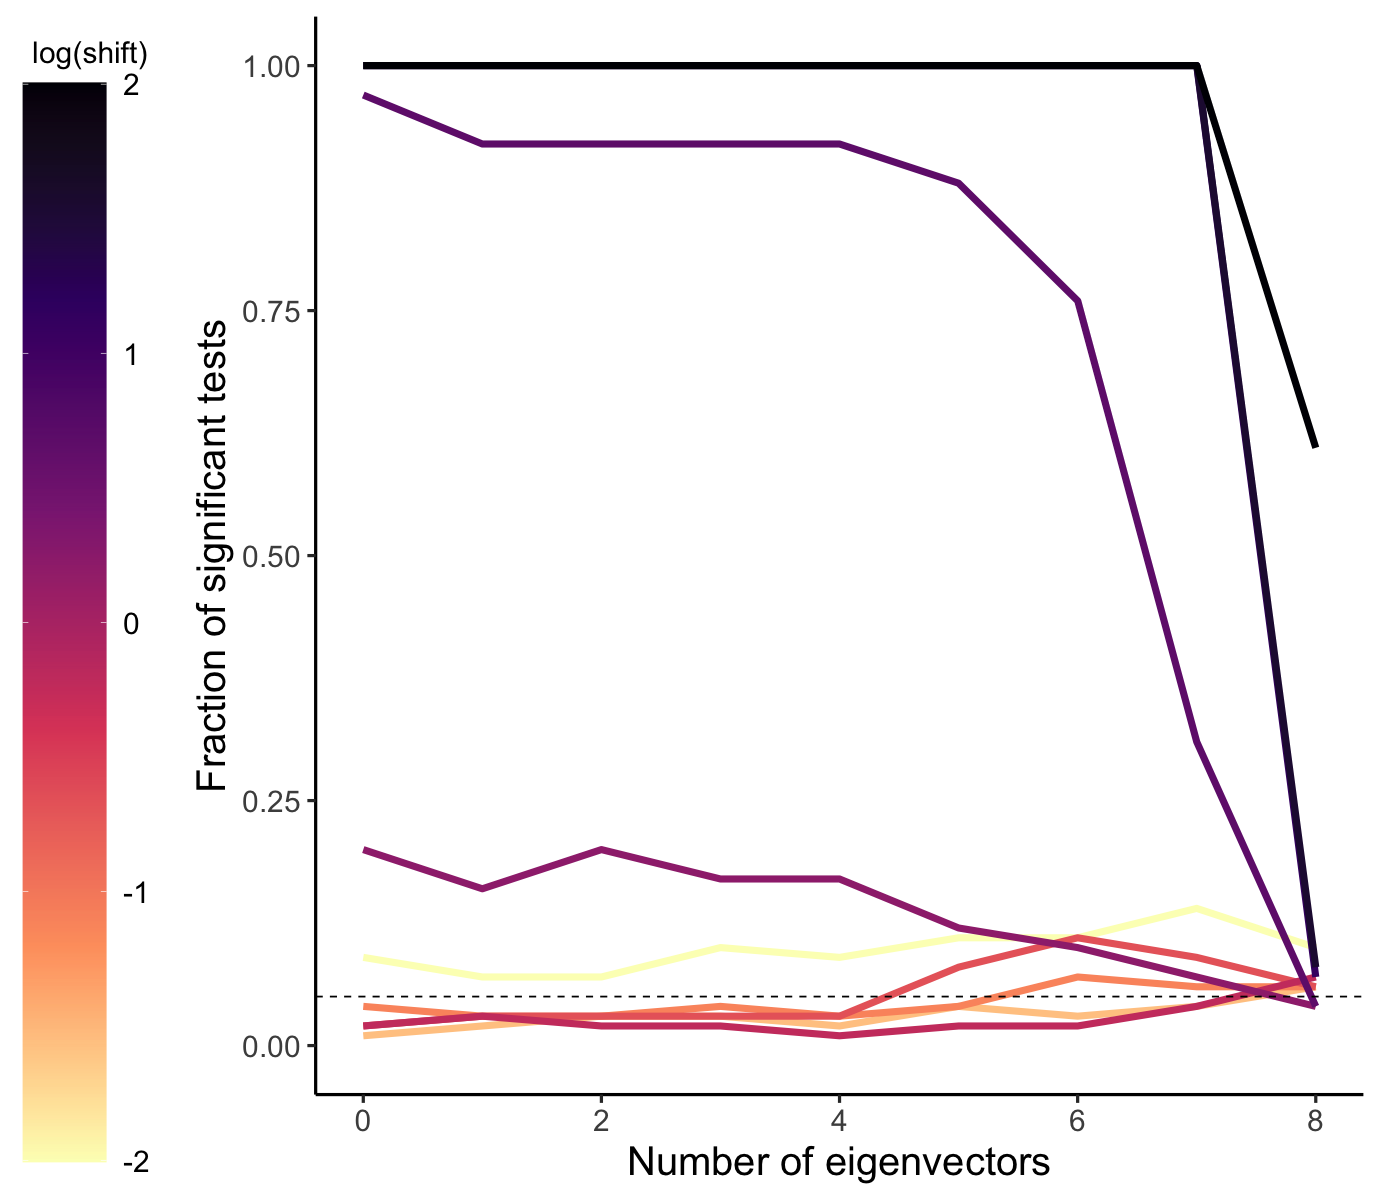

In [26]:
options(repr.plot.width = 11.5, repr.plot.height = 10)

plot_shift_9 <- p_vals_PC_summary_9 %>%
    ggplot(aes(PCs,FPR, group = mean.shift)) +
    geom_line(aes(color = log10(mean.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) +
    theme(
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          legend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "magma",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(shift)"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 3.5,               # width of color bar
           barheight = 45              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

legend_9 <- get_legend(plot_shift_9)

plot_shift_9_no_legend <- plot_shift_9 + theme(legend.position = "none")

final_plot_9 <- plot_grid(
  legend_9, plot_shift_9_no_legend,
  ncol = 2,
  rel_widths = c(0.15, 1),
  align = "none"
)

final_plot_9

ggsave("Figures_raw/Figure_4_3.9_mean.pdf", final_plot_9, width = 11.5, height = 10)
ggsave("Figures_raw/Figure_4_3.9_mean.svg", final_plot_9, width = 11.5, height = 10)

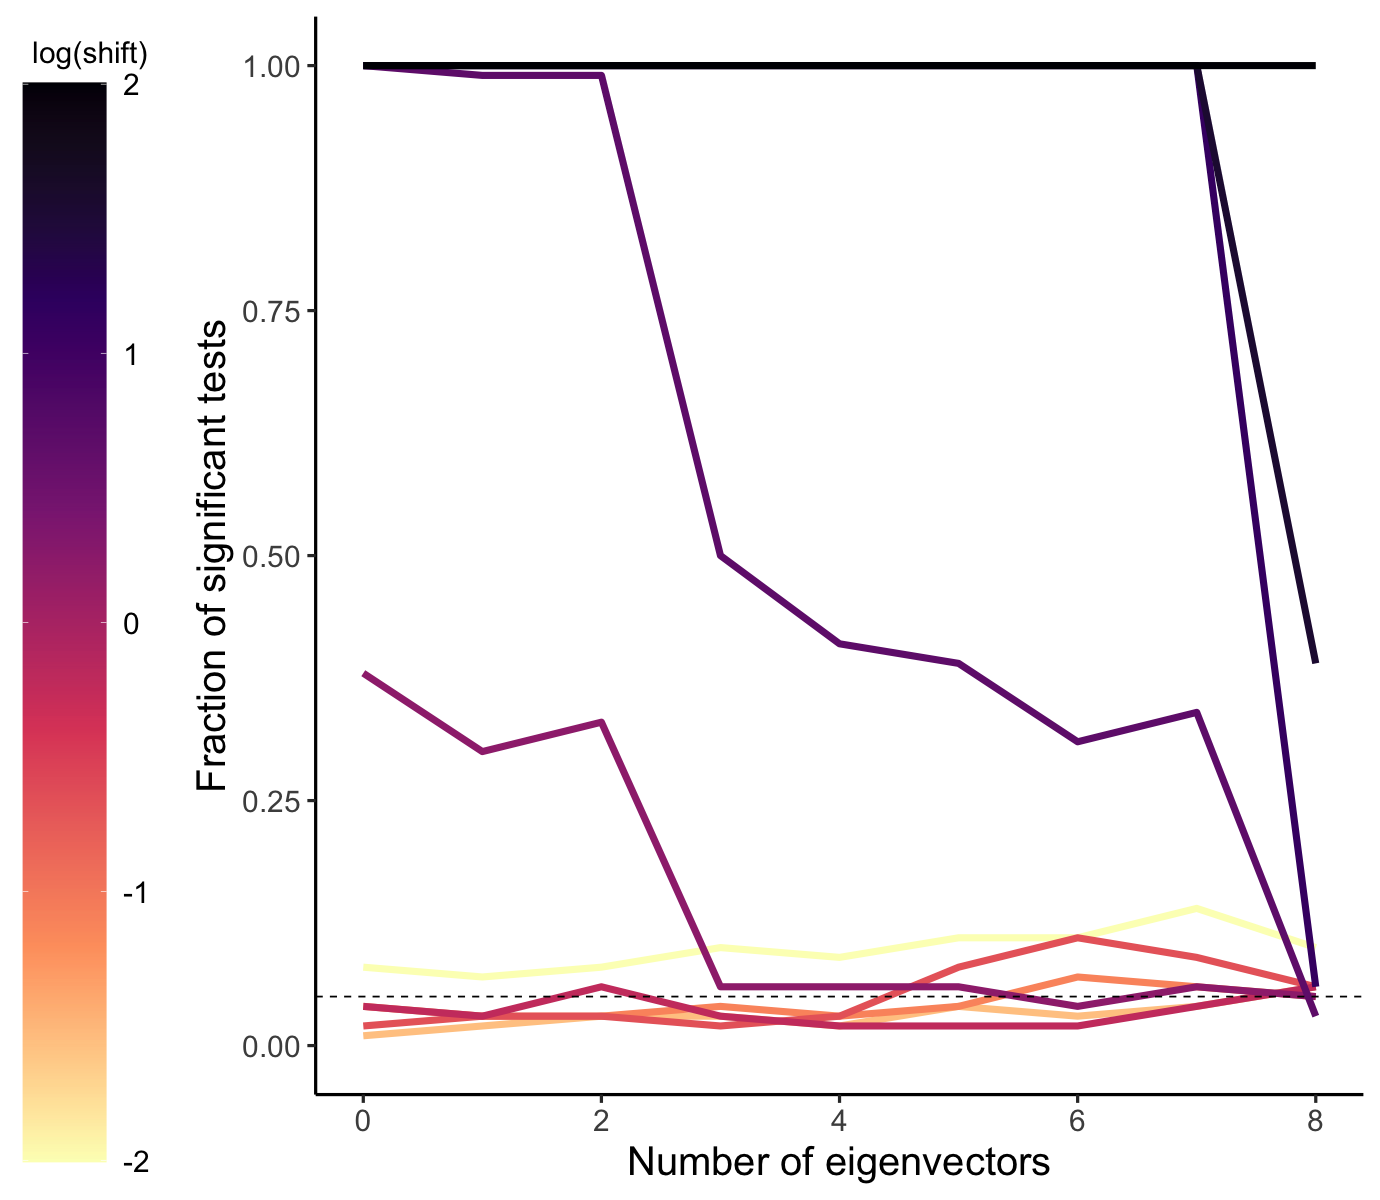

In [27]:
options(repr.plot.width = 11.5, repr.plot.height = 10)

plot_shift_13 <- p_vals_PC_summary_13 %>%
    ggplot(aes(PCs,FPR, group = mean.shift)) +
    geom_line(aes(color = log10(mean.shift)), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("Number of eigenvectors") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) +
    theme(
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          legend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
    scale_color_viridis_c(
          option = "magma",          # choose viridis scheme
          direction = -1,              # reverse scale: higher = darker/bluer
          name = "log(shift)"            # colorbar title
    ) +
    guides(color = guide_colorbar(
           title.hjust = 0.5,
           barwidth = 3.5,               # width of color bar
           barheight = 45              # height of color bar
    )) +
    theme(legend.title = element_text(size = 18),  # font for title
          legend.text  = element_text(size = 18) # font for ticks
    )

legend_13 <- get_legend(plot_shift_13)

plot_shift_13_no_legend <- plot_shift_13 + theme(legend.position = "none")

final_plot_13 <- plot_grid(
  legend_13, plot_shift_13_no_legend,
  ncol = 2,
  rel_widths = c(0.15, 1),
  align = "none"
)

final_plot_13

ggsave("Figures_raw/Figure_4_3.10_mean.pdf", final_plot_13, width = 11.5, height = 10)
ggsave("Figures_raw/Figure_4_3.10_mean.svg", final_plot_13, width = 11.5, height = 10)

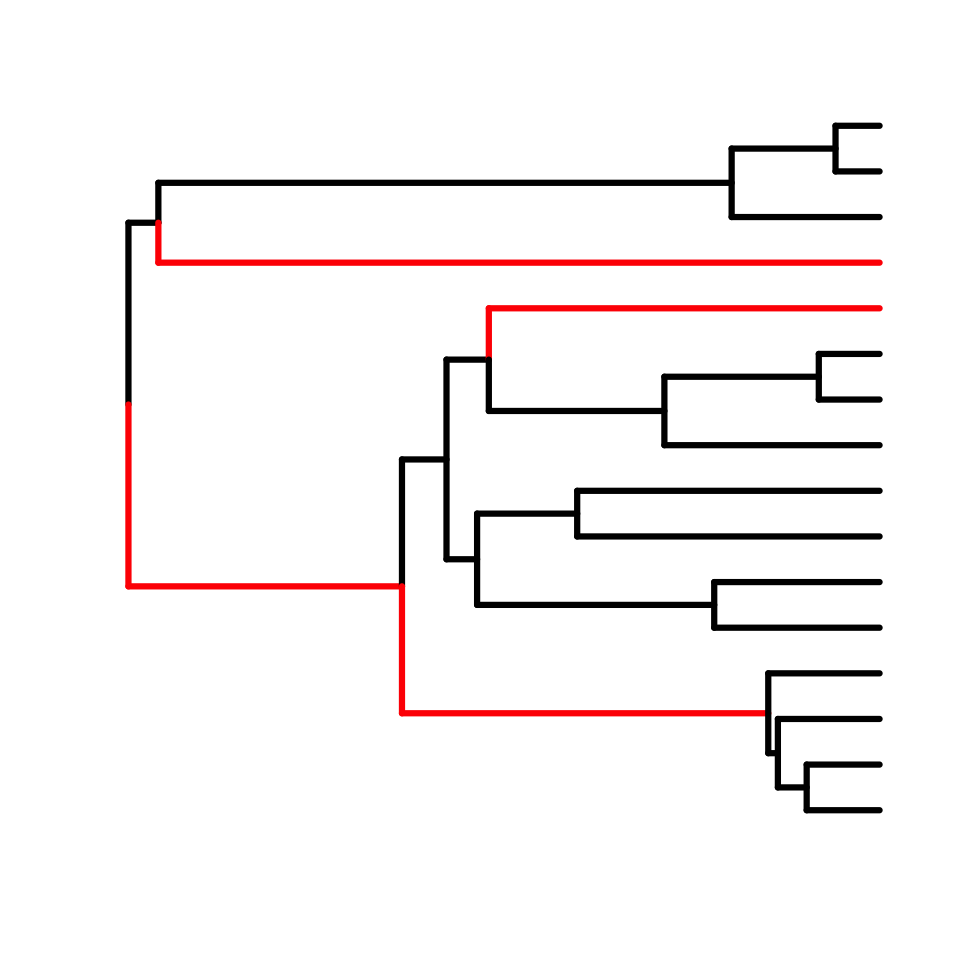

In [28]:
edge_c = rep("black", n_edges)
edge_c[c(1, 2, 23, 25)] = "red"
options(repr.plot.width = 8, repr.plot.height = 8)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)

In [29]:
svg("Figures_raw/PC_contributions_Fig_4_3.11.svg", width = 11.5, height = 10)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)
dev.off()

pdf 
  2

In [30]:
pdf("Figures_raw/PC_contributions_Fig_4_3.11.pdf", width = 11.5, height = 10)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)
dev.off()

pdf 
  2

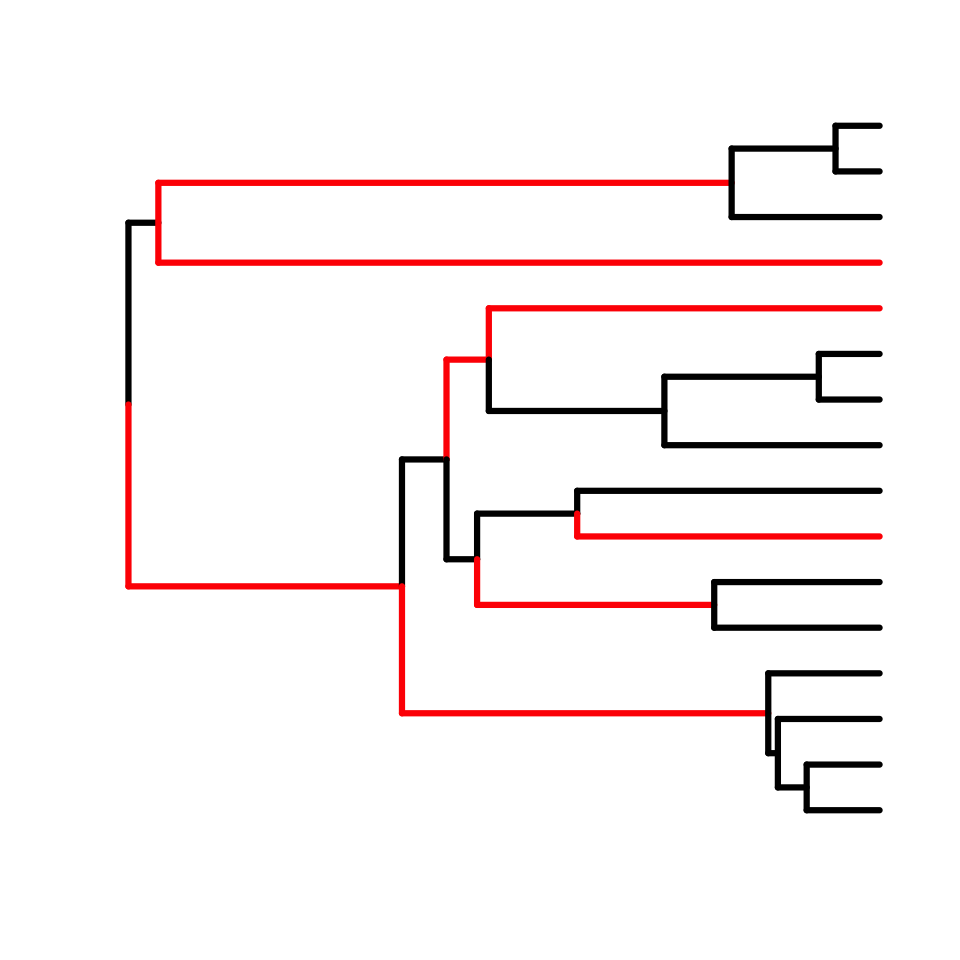

In [31]:
edge_c = rep("black", n_edges)
edge_c[c(1, 2, 11, 15, 17, 23, 25, 26)] = "red"
options(repr.plot.width = 8, repr.plot.height = 8)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)

In [32]:
svg("Figures_raw/PC_contributions_Fig_4_3.12.svg", width = 11.5, height = 10)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)
dev.off()

pdf 
  2

In [33]:
pdf("Figures_raw/PC_contributions_Fig_4_3.12.pdf", width = 11.5, height = 10)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)
dev.off()

pdf 
  2

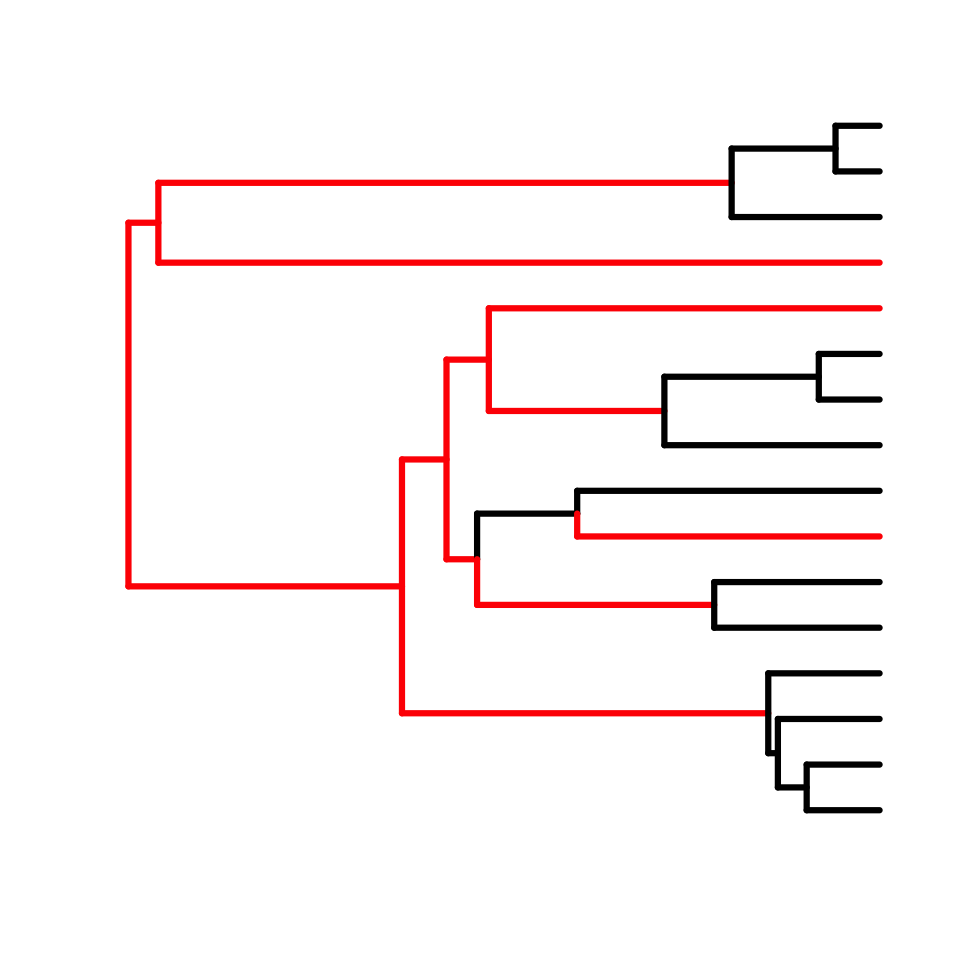

In [34]:
edge_c = rep("black", n_edges)
edge_c[c(1, 2, 9, 10, 11, 15, 17, 18, 23, 24, 25, 26)] = "red"
options(repr.plot.width = 8, repr.plot.height = 8)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)

In [35]:
svg("Figures_raw/PC_contributions_Fig_4_3.13.svg", width = 11.5, height = 10)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)
dev.off()

pdf 
  2

In [36]:
pdf("Figures_raw/PC_contributions_Fig_4_3.13.pdf", width = 11.5, height = 10)
plot.phylo(yule_tree, edge.color = edge_c, edge.width = 5, show.tip.label = FALSE)
dev.off()

pdf 
  2